<a href="https://colab.research.google.com/github/makxxic/ICP-YDR32P-2026-REPO/blob/main/project2_Regression_for_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Problem Definition

In this project, the aim is to predict house prices using various numerical features such as income, location, and population.

This is a regression problem because:

The target variable (MedHouseVal) is continuous.

## 2. Import Libraries
Import essential libraries:

Data handling → pandas

Visualization → matplotlib

Machine learning → sklearn, xgboost

Numerical operations →  numpy

Modeling  → sklearn

In [22]:
import pandas as pd # Import pandas for data manipulation and analysis
import numpy as np # Import numpy for numerical operations
import matplotlib.pyplot as plt # Import matplotlib for creating static, interactive, and animated visualizations
import seaborn as sns # Import seaborn for statistical data visualization

from sklearn.datasets import fetch_california_housing # Import function to fetch the California housing dataset
from sklearn.model_selection import train_test_split # Import function to split data into training and testing sets
from sklearn.preprocessing import StandardScaler # Import StandardScaler for feature scaling

from sklearn.linear_model import LinearRegression # Import Linear Regression model
from sklearn.ensemble import RandomForestRegressor # Import Random Forest Regressor model

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score # Import metrics for model evaluation

# Advanced model imports
from xgboost import XGBRegressor # Import XGBoost Regressor model
import tensorflow as tf # Import TensorFlow for deep learning
from tensorflow.keras.models import Sequential # Import Sequential model for building neural networks
from tensorflow.keras.layers import Dense # Import Dense layer for neural networks
from tensorflow.keras.callbacks import EarlyStopping # Import EarlyStopping for preventing overfitting during training

## 3. Load Dataset

Load dataset into a DataFrame for analysis, use the California Housing dataset, a standard dataset for regression tasks.

In [23]:
data = fetch_california_housing(as_frame=True) # Load the California housing dataset into a Bunch object, as a pandas DataFrame
df = data.frame # Extract the DataFrame containing features and target variable

df.head() # Display the first 5 rows of the DataFrame

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 4. Data Exploration

Check:

Missing values

Data types

Statistical summary

Target variable

In [24]:
df.info() # Print a concise summary of the DataFrame, including data types and non-null values
df.describe() # Generate descriptive statistics of the DataFrame's numerical columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


## 5. Data Visualization

Visualize correlations to understand relationships between features and price.

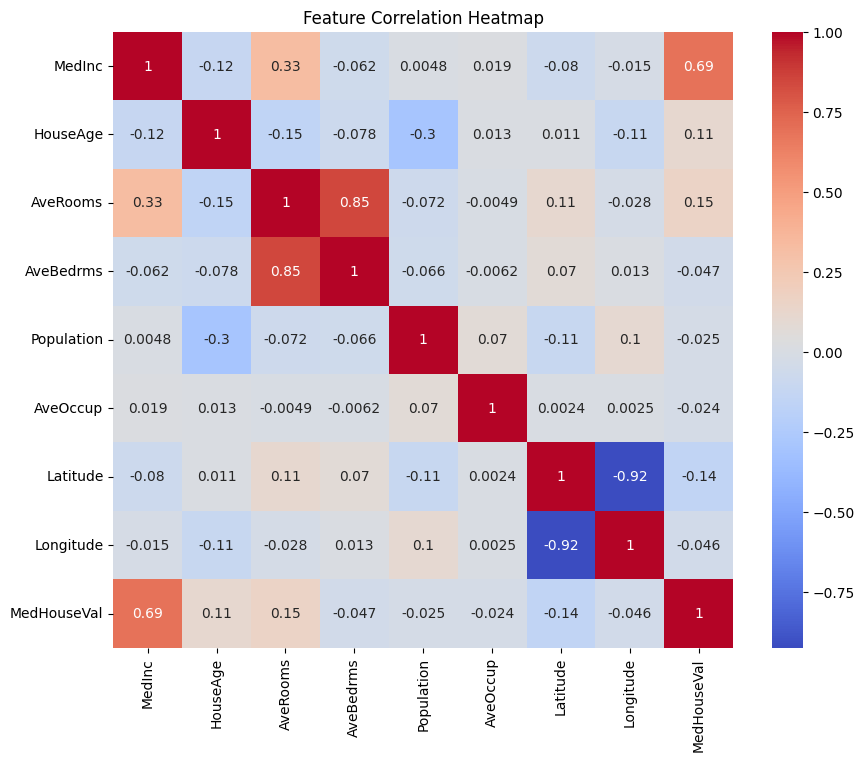

In [25]:
plt.figure(figsize=(10,8)) # Create a new figure with a specified size
sns.heatmap(df.corr(), annot=True, cmap='coolwarm') # Generate a heatmap of the correlation matrix, with annotations and a 'coolwarm' colormap
plt.title("Feature Correlation Heatmap") # Set the title of the heatmap
plt.show() # Display the plot

## 6. Define Features and Target
Separate:

X → input features

y → target variable (house price)

In [26]:
X = df.drop('MedHouseVal', axis=1) # Create feature DataFrame X by dropping the target column 'MedHouseVal'
y = df['MedHouseVal'] # Create target Series y with the 'MedHouseVal' column

## 7. Train-Test Split
Split data into training and testing sets evaluate model performance on unseen data.

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42 # Split the data into training and testing sets (80% train, 20% test) with a fixed random state
)

## 8. Feature Scaling

Scaling ensures all features are on the same scale, improving performance for linear models.

In [28]:
scaler = StandardScaler() # Initialize the StandardScaler

X_train_scaled = scaler.fit_transform(X_train) # Fit the scaler to the training data and transform it
X_test_scaled = scaler.transform(X_test) # Transform the test data using the fitted scaler

## 9. Train Model 1: Linear Regression (Baseline)

Start simple to establish a baseline.:

Linear Regression is fast and interpretable

In [29]:
lr_model = LinearRegression() # Initialize the Linear Regression model
lr_model.fit(X_train_scaled, y_train) # Train the Linear Regression model using scaled training data

lr_pred = lr_model.predict(X_test_scaled) # Make predictions on the scaled test data

## Evaluate Linear Regression
Measure performance by computing:

MAE → average error

RMSE → penalizes large errors

R² → how well model explains variance(goodness of fit)

In [30]:
def evaluate_model(y_true, y_pred, model_name): # Define a function to evaluate model performance
    mae = mean_absolute_error(y_true, y_pred) # Calculate Mean Absolute Error (MAE)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred)) # Calculate Root Mean Squared Error (RMSE)
    r2 = r2_score(y_true, y_pred) # Calculate R-squared score (R2)

    print(f"{model_name} Performance:") # Print the model name
    print("MAE:", mae) # Print MAE
    print("RMSE:", rmse) # Print RMSE
    print("R2 Score:", r2) # Print R2 Score
    print("-"*30) # Print a separator line

evaluate_model(y_test, lr_pred, "Linear Regression") # Call the evaluation function for Linear Regression

Linear Regression Performance:
MAE: 0.5332001304956565
RMSE: 0.7455813830127763
R2 Score: 0.575787706032451
------------------------------


## 10. Model 2: Random Forest

Tree-based models capture non-linear relationships better therefore usually performs better.

In [31]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42) # Initialize Random Forest Regressor with 100 trees and a fixed random state
rf_model.fit(X_train, y_train) # Train the Random Forest model using the training data

rf_pred = rf_model.predict(X_test) # Make predictions on the test data

evaluate_model(y_test, rf_pred, "Random Forest") # Evaluate the Random Forest model performance

Random Forest Performance:
MAE: 0.32754256845930246
RMSE: 0.5053399773665033
R2 Score: 0.8051230593157366
------------------------------


## 11. Model 3: XGBoost (Advanced)

XGBoost is a powerful boosting algorithm widely used in  real-world systems.

In [32]:
xgb_model = XGBRegressor( # Initialize XGBoost Regressor model
    n_estimators=200, # Set the number of boosting rounds to 200
    learning_rate=0.05, # Set the learning rate to 0.05
    max_depth=5, # Set the maximum tree depth to 5
    random_state=42 # Set a fixed random state for reproducibility
)

xgb_model.fit(X_train, y_train) # Train the XGBoost model using the training data

xgb_pred = xgb_model.predict(X_test) # Make predictions on the test data

evaluate_model(y_test, xgb_pred, "XGBoost") # Evaluate the XGBoost model performance

XGBoost Performance:
MAE: 0.3307314071974574
RMSE: 0.4925097476637183
R2 Score: 0.8148930176978784
------------------------------


## 12. Feature Importance

Shows which features most influence predictions.

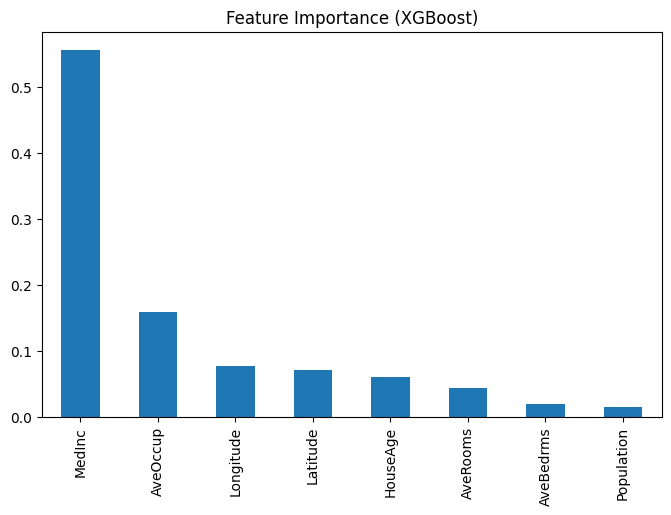

In [33]:
importances = pd.Series( # Create a pandas Series for feature importances
    xgb_model.feature_importances_, # Get feature importances from the trained XGBoost model
    index=X.columns # Use feature names as the index
).sort_values(ascending=False) # Sort feature importances in descending order

plt.figure(figsize=(8,5)) # Create a new figure with a specified size
importances.plot(kind='bar') # Plot feature importances as a bar chart
plt.title("Feature Importance (XGBoost)") # Set the title of the plot
plt.show() # Display the plot

## 14. Hyperparameter Tuning

In [34]:
from sklearn.model_selection import GridSearchCV # Import GridSearchCV for hyperparameter tuning

param_grid = { # Define the parameter grid for GridSearchCV
    'n_estimators': [100, 200], # Number of boosting rounds
    'max_depth': [3, 5, 7] # Maximum tree depth
}

grid = GridSearchCV(XGBRegressor(), param_grid, cv=3) # Initialize GridSearchCV with XGBoost, the parameter grid, and 3-fold cross-validation
grid.fit(X_train, y_train) # Fit GridSearchCV to the training data to find the best parameters

print("Best Params:", grid.best_params_) # Print the best parameters found by GridSearchCV

Best Params: {'max_depth': 5, 'n_estimators': 200}


## 15. Model 4: Deep Learning (Neural Network)
Prepare Data for Neural Network

Neural networks perform better when:

Data is scale
d
Input is in array format

We will reuse the scaled data (X_train_scaled, X_test_scaled).

In [35]:
X_train_nn = X_train_scaled # Assign scaled training features to X_train_nn for neural network input
X_test_nn = X_test_scaled # Assign scaled test features to X_test_nn for neural network input

## Build Neural Network Model

Create a simple feedforward neural network:

Input layer → takes features

Hidden layers → learn patterns

Output layer → predicts price

In [36]:
nn_model = Sequential([ # Initialize a Sequential neural network model
    Dense(64, activation='relu', input_shape=(X_train_nn.shape[1],)), # Add a dense (fully connected) layer with 64 units, ReLU activation, and input shape defined by the number of features
    Dense(32, activation='relu'), # Add another dense layer with 32 units and ReLU activation
    Dense(1)  # Add the output layer with 1 unit for regression (no activation function for linear output)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Compile the Model

We define:

Loss → Mean Squared Error (best for regression)

Optimizer → Adam (efficient training)

In [37]:
nn_model.compile( # Compile the neural network model
    optimizer='adam', # Use the Adam optimizer for efficient training
    loss='mse', # Use Mean Squared Error as the loss function, suitable for regression
    metrics=['mae'] # Monitor Mean Absolute Error during training
)

## Add Early Stopping

Stops training when performance stops improving → prevents overfitting.

In [38]:
early_stop = EarlyStopping( # Initialize EarlyStopping callback
    monitor='val_loss', # Monitor the validation loss
    patience=5, # Stop training if validation loss does not improve for 5 epochs
    restore_best_weights=True # Restore model weights from the epoch with the best validation loss
)

## Train the Model

Train the model on training data and validate on test data.

In [39]:
history = nn_model.fit( # Train the neural network model
    X_train_nn, y_train, # Training data (features and target)
    validation_split=0.2, # Use 20% of the training data for validation
    epochs=50, # Train for a maximum of 50 epochs
    batch_size=32, # Use a batch size of 32 samples per gradient update
    callbacks=[early_stop], # Apply the EarlyStopping callback
    verbose=1 # Display training progress for each epoch
)

Epoch 1/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.9907 - mae: 0.6528 - val_loss: 0.4992 - val_mae: 0.5278
Epoch 2/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4210 - mae: 0.4597 - val_loss: 0.4323 - val_mae: 0.4673
Epoch 3/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4002 - mae: 0.4404 - val_loss: 0.3927 - val_mae: 0.4377
Epoch 4/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3589 - mae: 0.4251 - val_loss: 0.3849 - val_mae: 0.4360
Epoch 5/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3452 - mae: 0.4167 - val_loss: 0.3857 - val_mae: 0.4464
Epoch 6/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3485 - mae: 0.4141 - val_loss: 0.3694 - val_mae: 0.4359
Epoch 7/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3315 - mae: 0.4053 - val_loss: 0.3554 - val_mae: 0.4184
Epoch 8/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3220 - mae: 0.3996 - val_loss: 0.3572 - val_mae: 0.4195
Epoch 9/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - lo

## Evaluate Neural Network

Compare its performance with other models.

In [40]:
nn_pred = nn_model.predict(X_test_nn) # Make predictions on the scaled test data using the trained neural network

evaluate_model(y_test, nn_pred, "Neural Network") # Evaluate the neural network model performance

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Neural Network Performance:
MAE: 0.36440135453404615
RMSE: 0.5375712185753889
R2 Score: 0.7794712797003568
------------------------------


## Plot Training Performance

Visualizing loss helps understand model learning behavior.

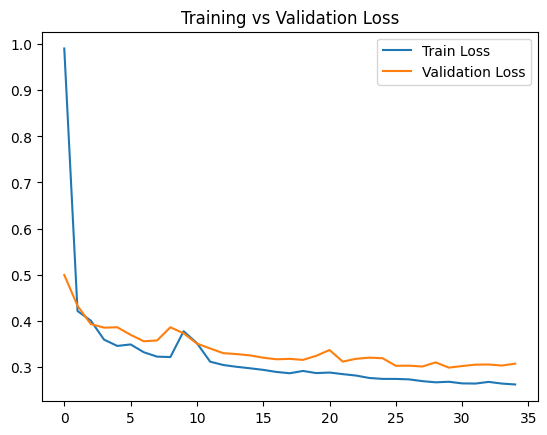

In [41]:
plt.plot(history.history['loss'], label='Train Loss') # Plot the training loss over epochs
plt.plot(history.history['val_loss'], label='Validation Loss') # Plot the validation loss over epochs
plt.legend() # Display the legend for the plot
plt.title("Training vs Validation Loss") # Set the title of the plot
plt.show() # Display the plot

13. Model Comparison

Comparing all models clearly.

In [42]:
results = pd.DataFrame({ # Create a pandas DataFrame to store model comparison results
    "Model": ["Linear Regression", "Random Forest", "XGBoost", "Neural Network"], # Column for model names
    "R2 Score": [ # Column for R2 scores
        r2_score(y_test, lr_pred), # R2 score for Linear Regression
        r2_score(y_test, rf_pred), # R2 score for Random Forest
        r2_score(y_test, xgb_pred), # R2 score for XGBoost
        r2_score(y_test, nn_pred) # R2 score for Neural Network
    ]
})

results # Display the results DataFrame

,Model,R2 Score
0,Linear Regression,0.575788
1,Random Forest,0.805123
2,XGBoost,0.814893
3,Neural Network,0.779471


## 17. Final Conclusion
XGBoost achieved the highest R² score, indicating it best captured the underlying patterns in the data.

 Random Forest also performed well due to its ability to model non-linear relationships.

  The Neural Network showed competitive performan
  
  Linear Regression performed the worst due to its inability to model complex relationships.